# Treinamento de Uma Rede Neural MPL (Regressão)

In [ ]:
import pandas as pd

In [ ]:
# Lendo o dataset
df = pd.read_csv('casas_california.csv')

In [18]:
# Plotando um mapa com as coordenadas (latitude e longitude)
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat='latitude',
    lon='longitude',
    color = 'valor_mediano_imoveis',
    hover_data= ['renda_mediana', 'populacao'],
    zoom=5
)

fig.update_layout(mapbox_style='open-street-map')
fig.show()

In [19]:
df1 = df[df["valor_mediano_imoveis"] < 50000]

fig = px.scatter_mapbox(
  df1,
  lat="latitude",
  lon="longitude",
  color="valor_mediano_imoveis",
  hover_data=[
    "valor_mediano_imoveis",
    "renda_mediana",
    "populacao"
  ],
  zoom=5)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [20]:
import folium

mapa = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=5
)

for _, row in df1.iterrows():
  folium.CircleMarker(
      location=[row['latitude'], row['longitude']],
      radius=3,
      popup=f"""
        Preço: {row['valor_mediano_imoveis']} <br>
        Renda: {row['renda_mediana']} <br>
        População: {row['populacao']}
      """,
      color="blue",
      fill=True).add_to(mapa)
mapa

In [21]:
# Preparação dos dados
x = df[[
    'longitude',
    'latitude',
    'idade_mediana_imoveis',
    'total_comodos',
    'populacao',
    'domicilios',
    'renda_mediana'
]]

y = df['valor_mediano_imoveis']

In [22]:
# Normalização dos dados (standard scale)
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Normalização das entradas
x_scaled = scaler_x.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

# Normalização da saída
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [23]:
# Preparação dos dados para treino e teste
from sklearn.model_selection import train_test_split

xtreino, xteste, ytreino, yteste = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

In [24]:
# Preparação dos parâmetros do modelo
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
  hidden_layer_sizes=(64, 32),
  max_iter=300,
  n_iter_no_change=300,
  random_state=42,
  verbose=True
)

mlp.fit(xtreino, ytreino)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Iteration 1, loss = 0.26530370
Iteration 2, loss = 0.17131590
Iteration 3, loss = 0.15084095
Iteration 4, loss = 0.14237377
Iteration 5, loss = 0.13691720
Iteration 6, loss = 0.13196785
Iteration 7, loss = 0.12858105
Iteration 8, loss = 0.12520888
Iteration 9, loss = 0.12253386
Iteration 10, loss = 0.12031426
Iteration 11, loss = 0.11815762
Iteration 12, loss = 0.11640354
Iteration 13, loss = 0.11485160
Iteration 14, loss = 0.11380957
Iteration 15, loss = 0.11242884
Iteration 16, loss = 0.11133462
Iteration 17, loss = 0.11026029
Iteration 18, loss = 0.11024414
Iteration 19, loss = 0.10845505
Iteration 20, loss = 0.10807557
Iteration 21, loss = 0.10753195
Iteration 22, loss = 0.10671871
Iteration 23, loss = 0.10642643
Iteration 24, loss = 0.10558446
Iteration 25, loss = 0.10501651
Iteration 26, loss = 0.10453245
Iteration 27, loss = 0.10387759
Iteration 28, loss = 0.10341801
Iteration 29, loss = 0.10300537
Iteration 30, loss = 0.10261284
Iteration 31, loss = 0.10267898
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.



MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, n_iter_no_change=300,
             random_state=42, verbose=True)

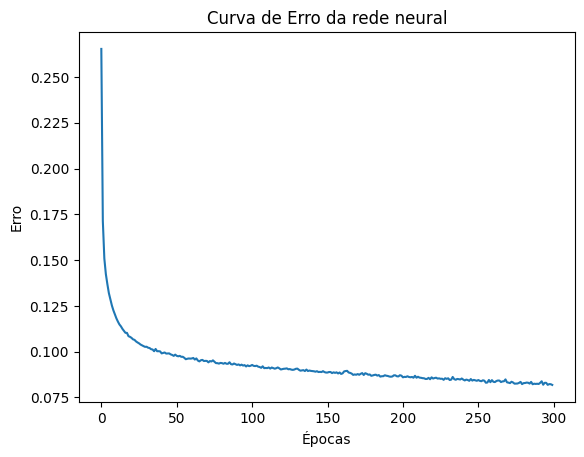

In [25]:
from matplotlib import pyplot as plt

plt.plot(mlp.loss_curve_)
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.title('Curva de Erro da rede neural')
plt.show()

In [26]:
# Previsão para os dados de treino
ypred_treino_scaled = mlp.predict(xtreino)
ypred_treino = scaler_y.inverse_transform(ypred_treino_scaled.reshape(-1, 1))
ytreino_original = scaler_y.inverse_transform(ytreino)

In [27]:
# Previsão para os dados de teste
ypred_teste_scaled = mlp.predict(xteste)
ypred_teste = scaler_y.inverse_transform(ypred_teste_scaled.reshape(-1, 1))
yteste_original = scaler_y.inverse_transform(yteste)

In [28]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error

# Resultados para o treino
print("Resultados - Treino")
print("MAPE: {:.2f}%".format(mean_absolute_percentage_error(ytreino_original, ypred_treino) * 100))
print("R2: {:.2f}".format(r2_score(ytreino_original, ypred_treino)))

Resultados - Treino
MAPE: 18.38%
R2: 0.84


In [29]:
# Resultados para teste
print("\nRsultados - Teste")
print("MAPE: {:.2f}%".format(mean_absolute_percentage_error(yteste_original, ypred_teste) * 100))
print("R2: {:.2f}".format(r2_score(yteste_original, ypred_teste)))


Rsultados - Teste
MAPE: 20.72%
R2: 0.79


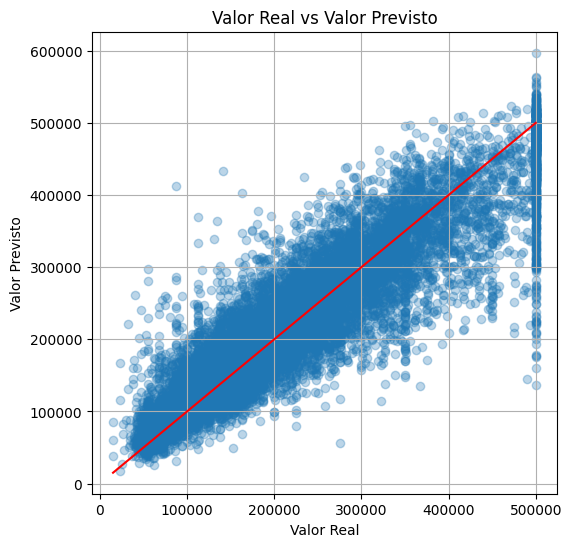

In [31]:
# Scatter (Real x previsto) para os dados de treino
plt.figure(figsize=(6, 6))

plt.scatter(ytreino_original, ypred_treino, alpha=0.3)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valor Real vs Valor Previsto")
plt.plot(
    [ytreino_original.min(), ytreino_original.max()],
    [ytreino_original.min(), ytreino_original.max()],
    color="red"
)

plt.grid(True)

plt.show()

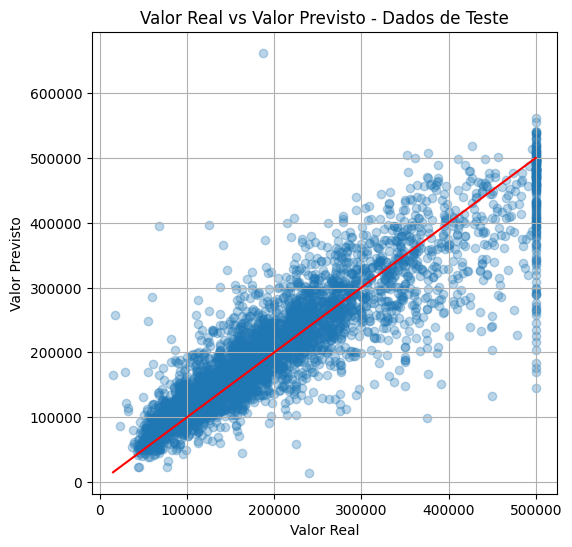

In [32]:
# Scatter (Real x Previsto) para os dados de teste
plt.figure(figsize=(6, 6))

plt.scatter(yteste_original, ypred_teste, alpha=0.3)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valor Real vs Valor Previsto - Dados de Teste")
plt.plot(
    [yteste_original.min(), yteste_original.max()],
    [yteste_original.min(), yteste_original.max()],
    color="red"
)

plt.grid(True)
plt.show()